In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.collections import LineCollection
import matplotlib.pyplot as plt
import scipy.stats as stats


from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LinearRegression
from sklearn.utils import check_random_state
from sklearn.metrics import mean_squared_error 



ImportError: C extension: None not built. If you want to import pandas from the source directory, you may need to run 'python setup.py build_ext' to build the C extensions first.

In [2]:
import os
#os.chdir(os.getcwd()+"/code")

In [2]:
from ir_visualize import plot_isotonic_regression_fit 
from ir_model_fit import isotonic_regression_fit
from inverse_prediction import isotonic_regression_fit_inverse
from ir_visualize_IC50 import plot_isotonic_regression_fit_IC50
from inverse_prediction_bootsrap95CI import isotonic_regression_fit_inverse_bootstrap
from ir_model_fit_logscale import isotonic_regression_fit_logscale

In [3]:
# Load datasets --

# 3 rep simulations 
sim_3rep = pd.read_csv('../Sim_Datasets/n_1000/sim_3rep_9dose_0.2outlier.csv')
~

In [4]:
sim_3rep.head(10)

,dose,replicate,log_intensity,protein,protein_group,sample_group,outlier,intensity
0,0,1,5.136556,p_strong_interaction_1,strong_interaction,DMSO,False,35.176901
1,0,2,5.320644,p_strong_interaction_1,strong_interaction,DMSO,False,39.964402
2,0,3,5.472255,p_strong_interaction_1,strong_interaction,DMSO,False,44.392834
3,1,1,7.909742,p_strong_interaction_1,strong_interaction,treated,True,240.474861
4,1,2,5.334182,p_strong_interaction_1,strong_interaction,treated,False,40.341188
5,1,3,5.288625,p_strong_interaction_1,strong_interaction,treated,False,39.087231
6,3,1,4.771608,p_strong_interaction_1,strong_interaction,treated,False,27.314746
7,3,2,5.055186,p_strong_interaction_1,strong_interaction,treated,False,33.247779
8,3,3,4.412932,p_strong_interaction_1,strong_interaction,treated,False,21.302228
9,10,1,4.827742,p_strong_interaction_1,strong_interaction,treated,False,28.398476


In [17]:
# Define protein list and dataset for single protein test -- 
data = sim_3rep
protein = 'p_strong_interaction_1'


# Test inverse predict 
ic50 = isotonic_regression_fit_inverse(data = data, 
                                protein_name = protein)
ic50[0]


ic50CI = isotonic_regression_fit_inverse_bootstrap(data, protein)
ic50CI[1]
ic50[0]

log10(IC50) Estimation: 1.3284084791108604
IC50 Estimation: 21.30141625622542
log10(IC50) Estimation: 1.3284084791108604
IC50 Estimation: 21.30141625622542
95% CI for IC50: (20.835449721434152, 50.32475642772181)


1.3284084791108604

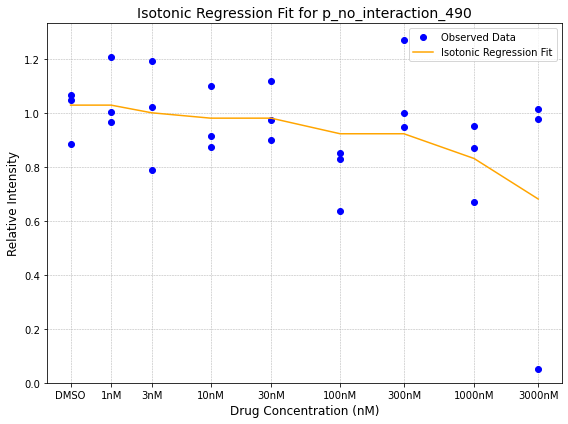

(array([0.        , 0.30103   , 0.60205999, 1.04139269, 1.49136169,
        2.00432137, 2.4785665 , 3.00043408, 3.477266  ]),
 array([1.02924348, 1.02924348, 1.00087983, 0.98091437, 0.98091437,
        0.92309272, 0.92309272, 0.83138945, 0.68121393]))

In [7]:
# check data 
# Define protein list and dataset for single protein test -- 
data = sim_3rep
protein = 'p_no_interaction_490'


plot_isotonic_regression_fit(data = data,
                                  protein_name = protein)
                                  

In [25]:
# Test model fit compared to null model ---


# Define protein list and dataset 
data = sim_3rep

protein_list = np.unique(data['protein'])

# run though all proteins 
pvalues = [] 
for protein in protein_list:
    ir_fit = isotonic_regression_fit_logscale(data = data, 
                        protein_name = protein)
    p_vals = ir_fit[3]
    pvalues.append(p_vals)
    

# combine proteins and p-values to a single dataframe 
model_res_all = {
    "protein": protein_list,  
    "p-value": pvalues                  
}

model_res_all = pd.DataFrame(model_res_all)

model_res_all_sort = model_res_all.sort_values(by='p-value', ascending=True)

# FDR pvalue adjustment 
model_res_all_sort['adj_pval'] = stats.false_discovery_control(
    model_res_all_sort['p-value'], method='bh')
model_res_all_sort.head()

,protein,p-value,adj_pval
1743,p_strong_interaction_768,3.330669e-16,6.661338e-13
1088,p_strong_interaction_178,3.774758e-15,3.404684e-12
1134,p_strong_interaction_219,5.107026e-15,3.404684e-12
1703,p_strong_interaction_731,1.709743e-14,6.883383e-12
1334,p_strong_interaction_4,1.720846e-14,6.883383e-12


In [26]:
# Total number of sig proteins 
model_res_all = model_res_all_sort 
p_sig_unadjust = len(model_res_all[model_res_all['p-value'] < .05])
p_sig_fdr_adjust = len(model_res_all[model_res_all['adj_pval'] < .05])

# count strong, weak , no interaction sig hits 
n_strong_sig = len(model_res_all[
    (model_res_all['adj_pval'] < 0.05) & 
    (model_res_all['protein'].str.contains('strong'))])
n_weak_sig = len(model_res_all[
    (model_res_all['adj_pval'] < 0.05) & 
    (model_res_all['protein'].str.contains('weak'))])
n_no_sig = len(model_res_all[
    (model_res_all['adj_pval'] < 0.05) & 
    (model_res_all['protein'].str.contains('no'))])

print("Number of sig proteins (p < .05):", p_sig_unadjust)
print("Number of sig proteins with FDR adjustment (p < .05):", p_sig_fdr_adjust)
print("Strong interaction hits:", n_strong_sig)
print("Weak interaction hits::", n_weak_sig)
print("No interaction hits::", n_no_sig)

Number of sig proteins (p < .05): 1000
Number of sig proteins with FDR adjustment (p < .05): 1000
Strong interaction hits: 1000
Weak interaction hits:: 0
No interaction hits:: 0


In [27]:
# save results file 
model_res_all.to_csv('../Sim_Datasets/n_1000/results/res_sim_template3_3rep_9dose.csv')


In [28]:
# Add additional filter based on IC50 prediction -- 
protein_list_sig = model_res_all[model_res_all['adj_pval'] < .05]['protein']


# run though all proteins 
ic50_estimate = [] 
ic50_estimate_lower = [] 
for protein in protein_list_sig:
    ic50CI = isotonic_regression_fit_inverse_bootstrap(data, 
                                                       protein)
    ic50 = ic50CI[0]
    ic50_lower = ic50CI[1]
    ic50_estimate.append(ic50)   
    ic50_estimate_lower.append(ic50_lower)
    
# combine into dataframe 
ic50_sig_proteins = pd.DataFrame({
    "protein": protein_list_sig,  
    "pval_adj": model_res_all[model_res_all['adj_pval'] < .05]['adj_pval'],
    "IC50": ic50_estimate,
    "IC50_CI": ic50_estimate_lower
    "CI_fit":
})

ic50_sig_proteins

log10(IC50) Estimation: 1.156544016038683
IC50 Estimation: 14.339830438399007
95% CI for IC50: (6.6332495807108, 35.40748946676564)
log10(IC50) Estimation: 1.1913823547169076
IC50 Estimation: 15.53754339925748
95% CI for IC50: (9.22983445082195, 34.475755887385006)
log10(IC50) Estimation: 0.7214382360466091
IC50 Estimation: 5.265483255727813
95% CI for IC50: (3.1227814654806716, 10.224709648835468)
log10(IC50) Estimation: 0.8759037203535198
IC50 Estimation: 7.514562836451813
95% CI for IC50: (nan, nan)
log10(IC50) Estimation: 0.45154499349597177
IC50 Estimation: 2.82842712474619
95% CI for IC50: (nan, nan)
log10(IC50) Estimation: 0.8984938921633993
IC50 Estimation: 7.915783219360812
95% CI for IC50: (2.1230383887307402, 27.384529433939058)
log10(IC50) Estimation: 0.9285652328002928
IC50 Estimation: 8.483307956243783
95% CI for IC50: (2.9962577553362437, 14.827855492366526)
log10(IC50) Estimation: 0.6286481229372705
IC50 Estimation: 4.252537215177368
95% CI for IC50: (2.0, 12.4192626633

,protein,pval_adj,IC50,IC50_CI
890,p_strong_interaction_46,0.000002,14.339830,6.633250
893,p_strong_interaction_49,0.000002,15.537543,9.229834
868,p_strong_interaction_26,0.000002,5.265483,3.122781
897,p_strong_interaction_7,0.000008,7.514563,NaN
879,p_strong_interaction_36,0.000008,2.828427,NaN
883,p_strong_interaction_4,0.000008,7.915783,2.123038
895,p_strong_interaction_50,0.000077,8.483308,2.996258
871,p_strong_interaction_29,0.000109,4.252537,2.000000
869,p_strong_interaction_27,0.000147,5.286348,2.536359
861,p_strong_interaction_2,0.000219,12.914113,4.723426
